## Smart City Traffic Prediction System

This project develops a Machine Learning system to analyze and predict traffic situations using historical traffic data.

The dataset contains information about vehicle counts such as cars, bikes, buses, and trucks, along with time and day information.

In [1]:
## Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading dataset

df = pd.read_csv("Traffic.csv")


In [3]:
#first 5 rows

df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [4]:
# Displays the last 5 records.

df.tail()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
2971,10:45:00 PM,9,Thursday,16,3,1,36,56,normal
2972,11:00:00 PM,9,Thursday,11,0,1,30,42,normal
2973,11:15:00 PM,9,Thursday,15,4,1,25,45,normal
2974,11:30:00 PM,9,Thursday,16,5,0,27,48,normal
2975,11:45:00 PM,9,Thursday,14,3,1,15,33,normal


In [5]:
# size od dataset

df.shape

(2976, 9)

In [6]:
# column names

df.columns

Index(['Time', 'Date', 'Day of the week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='str')

In [7]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Time               2976 non-null   str  
 1   Date               2976 non-null   int64
 2   Day of the week    2976 non-null   str  
 3   CarCount           2976 non-null   int64
 4   BikeCount          2976 non-null   int64
 5   BusCount           2976 non-null   int64
 6   TruckCount         2976 non-null   int64
 7   Total              2976 non-null   int64
 8   Traffic Situation  2976 non-null   str  
dtypes: int64(6), str(3)
memory usage: 275.4 KB


In [8]:
# checking missing values

df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

In [9]:
# summarry of data

df.describe()


,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000


### Initial Dataset Findings

The initial exploration helps us understand the structure and quality of the traffic dataset.

We have identified the available features, checked the data types, inspected missing values, and reviewed the statistical distribution of numerical variables.

The next step is to prepare the data for analysis by handling the time information and creating useful features.

In [10]:
# Check the Time values
df["Time"].head()

0    12:00:00 AM
1    12:15:00 AM
2    12:30:00 AM
3    12:45:00 AM
4     1:00:00 AM
Name: Time, dtype: str

### Converting the Time Column

The 'Time' column contains time values in 12-hour format with AM/PM.
We convert it into a datetime format so that we can extract useful information such as the hour.

In [11]:
# cpnverting time
df["Time"] = pd.to_datetime( df["Time"], format="%I:%M:%S %p")

### Creating the Hour Feature

The original dataset does not contain an Hour column.We create it from the Time column using the .dt.hour  property.

For example:

- 08:30 AM → 8
- 01:15 PM → 13
- 06:45 PM → 18

This is an example of **feature engineering**, where we create a useful machine learning feature from existing data.

In [12]:
# Creating Hour

df["Hour"] = df["Time"].dt.hour

In [13]:
df[["Time", "Hour"]].head(10)

,Time,Hour
0,1900-01-01 00:00:00,0
1,1900-01-01 00:15:00,0
2,1900-01-01 00:30:00,0
3,1900-01-01 00:45:00,0
4,1900-01-01 01:00:00,1
5,1900-01-01 01:15:00,1
6,1900-01-01 01:30:00,1
7,1900-01-01 01:45:00,1
8,1900-01-01 02:00:00,2
9,1900-01-01 02:15:00,2


### Feature Engineering Summary

A new Hour feature has been created from the Time column.

This feature represents the hour of the day from 0 to 23 and can help identify traffic patterns during different periods of the day.

For example, traffic may be different during:

- Morning hours
- Afternoon hours
- Evening rush hours
- Night hours

In [14]:
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour
0,1900-01-01 00:00:00,10,Tuesday,31,0,4,4,39,low,0
1,1900-01-01 00:15:00,10,Tuesday,49,0,3,3,55,low,0
2,1900-01-01 00:30:00,10,Tuesday,46,0,3,6,55,low,0
3,1900-01-01 00:45:00,10,Tuesday,51,0,2,5,58,low,0
4,1900-01-01 01:00:00,10,Tuesday,57,6,15,16,94,normal,1


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand patterns, relationships, and distributions in the dataset before building a machine learning model.

In [15]:
# checking the vehicle counts

df["Traffic Situation"].value_counts()

Traffic Situation
normal    1669
heavy      682
high       321
low        304
Name: count, dtype: int64

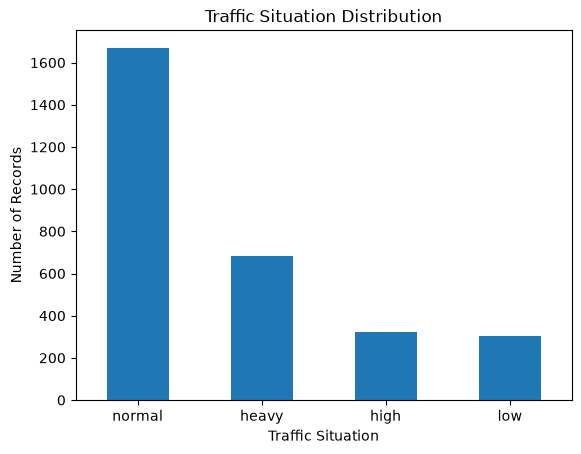

In [16]:
df["Traffic Situation"].value_counts().plot(kind="bar")

plt.title("Traffic Situation Distribution")
plt.xlabel("Traffic Situation")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

## Analysis

This chart shows the distribution of different traffic situations in the dataset.

It helps us understand whether the target classes are balanced or whether some traffic categories occur more frequently than others.

## Vehicle Count Distribution

We analyze the number of cars, bikes, buses, and trucks recorded in the dataset.

A box plot helps us identify the distribution and possible outliers in vehicle counts.

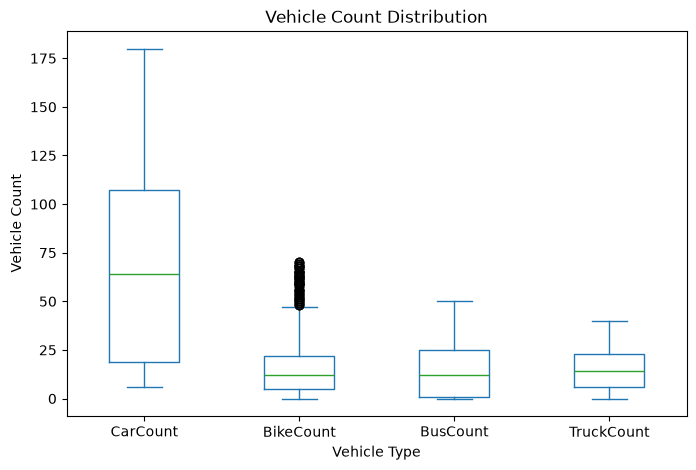

In [17]:
df[["CarCount", "BikeCount", "BusCount", "TruckCount"]].plot(
    kind="box",
    figsize=(8, 5)
)

plt.title("Vehicle Count Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Vehicle Count")
plt.show()

## Analysis

The box plot shows the spread of vehicle counts for different vehicle types.
It can also help identify unusually high or low observations that may represent outliers.

## Average Traffic by Hour

The Hour feature allows us to analyze how traffic volume changes throughout the day.We calculate the average total number of vehicles recorded for each hour.

In [18]:
hourly_traffic = df.groupby("Hour")["Total"].mean()

hourly_traffic

Hour
0      42.919355
1      42.314516
2      42.774194
3      47.266129
4      97.822581
5     114.580645
6     174.250000
7     172.403226
8     174.346774
9     134.959677
10    123.314516
11    104.709677
12    106.016129
13    130.153226
14    132.443548
15    122.322581
16    180.653226
17    181.048387
18    167.951613
19    123.572581
20    117.580645
21    122.419355
22     43.072581
23     42.346774
Name: Total, dtype: float64

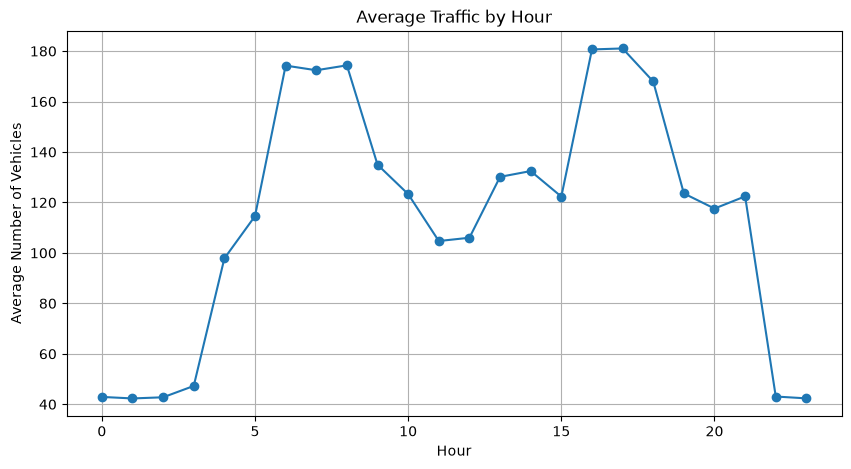

In [19]:
hourly_traffic.plot(kind="line", marker="o", figsize=(10, 5))

plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Number of Vehicles")
plt.grid()
plt.show()

## Analysis

The line chart shows how average traffic volume changes across different hours of the day.

Higher values indicate hours with greater average traffic volume. These patterns can help identify busy periods and potential rush hours.

## Total Vehicle Count by Vehicle Type

We compare the total number of cars, bikes, buses, and trucks recorded in the dataset.
This helps us understand which vehicle types contribute most to the overall traffic volume.

In [20]:
vehicle_counts = df[
    ["CarCount", "BikeCount", "BusCount", "TruckCount"]
].sum()

vehicle_counts

CarCount      204441
BikeCount      44394
BusCount       45472
TruckCount     45607
dtype: int64

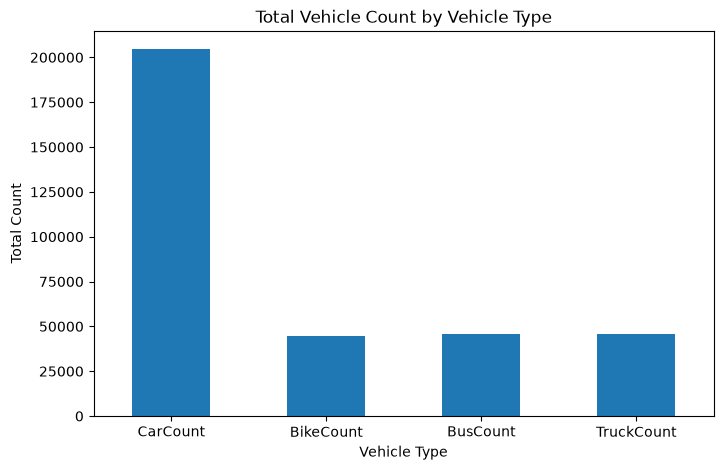

In [21]:
vehicle_counts.plot(kind="bar",figsize=(8, 5))

plt.title("Total Vehicle Count by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Count")
plt.xticks(rotation=0)
plt.show()

## Correlation Analysis

Correlation measures the relationship between numerical variables.

A correlation value close to:

- +1 indicates a strong positive relationship.
- 0 indicates little or no linear relationship.
- -1 indicates a strong negative relationship.

We will use a heatmap to visualize the correlations between traffic-related numerical features.

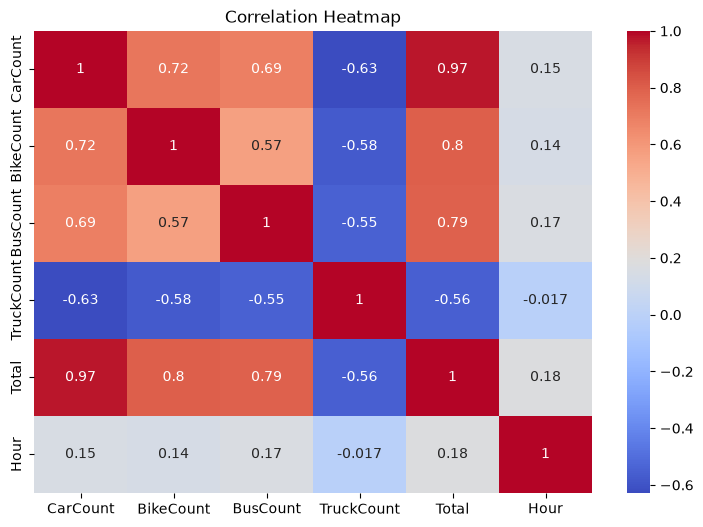

In [22]:
numeric_columns = [
    "CarCount",
    "BikeCount",
    "BusCount",
    "TruckCount",
    "Total",
    "Hour"
]

plt.figure(figsize=(9, 6))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## EDA Summary

The exploratory analysis helped us understand the traffic dataset and identify important patterns.

We analyzed:

- Distribution of traffic situations
- Vehicle count distributions
- Average traffic volume by hour
- Contribution of different vehicle types
- Correlations between numerical features

These findings help us select useful features for the machine learning model.

In [23]:
## Create Features X

X = df[
    [
        "CarCount",
        "BikeCount",
        "BusCount",
        "TruckCount",
        "Hour"
    ]
]

In [24]:
X.head()

,CarCount,BikeCount,BusCount,TruckCount,Hour
0,31,0,4,4,0
1,49,0,3,3,0
2,46,0,3,6,0
3,51,0,2,5,0
4,57,6,15,16,1


In [25]:
# creating target variable

y = df["Traffic Situation"]



In [26]:
y.head()

0       low
1       low
2       low
3       low
4    normal
Name: Traffic Situation, dtype: str

## Label Encoding

Machine learning algorithms generally work with numerical values.

The **Traffic Situation** column contains text categories, so we convert these categories into numerical labels using **LabelEncoder**.

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
## creating encoder
le = LabelEncoder()

In [29]:
y_encoded = le.fit_transform(y)

In [30]:
# result
y_encoded[:10]

array([2, 2, 2, 2, 3, 2, 2, 2, 2, 2])

In [31]:
for label, value in zip(le.classes_, le.transform(le.classes_)):
    print(label, "=", value)

heavy = 0
high = 1
low = 2
normal = 3


## Train-Test Split

We divide the dataset into two parts:

- **Training data (80%)** – used by the model to learn patterns.
- **Testing data (20%)** – used to evaluate the model on unseen data.

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
## splitting the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [34]:
# check the sizes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2380, 5)
X_test: (596, 5)
y_train: (2380,)
y_test: (596,)


### Train-Test Split Summary

The dataset has now been divided into training and testing sets.

The training data will be used to teach the machine learning model, while the testing data will remain unseen until evaluation.

The data is now ready for model training.

## Random Forest Classification Model

We will use the Random Forest Classifier to predict the traffic situation.

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make a final prediction.
It is suitable for this project because it can handle multiple numerical features and can capture complex relationships between traffic features.


In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
# creating model

model = RandomForestClassifier(n_estimators=100, random_state=42)

In [37]:
# train the model

model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Random Forest Training Summary

The Random Forest Classifier has now been trained using the training dataset.
The model has learned patterns between vehicle counts, time of day, and traffic situation.

In the next step, we will give the model the unseen `X_test` data and ask it to predict the traffic situation.
These predictions will then be compared with the actual `y_test` values to evaluate model performance.

In [38]:
# prediction

y_pred = model.predict(X_test)

In [39]:
## checking the prediction

y_pred[:10]

array([1, 0, 2, 2, 3, 2, 0, 2, 2, 3])

##  Model Evaluation

After making predictions, we need to evaluate how well our Random Forest model performed.
The first metric we will use is **Accuracy**.

Accuracy tells us the percentage of test observations that were predicted correctly.
For example, if the model correctly predicts 90 out of 100 observations:

Accuracy = 90%

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
# calculate accuracy

accuracy = accuracy_score(y_test,y_pred)


In [42]:
# show percentage
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 96.81 %


### Accuracy Analysis

The accuracy score represents the proportion of test observations that the model classified correctly.

A higher accuracy indicates that the model is making more correct predictions on the unseen test data.

However, accuracy alone may not provide a complete picture, especially when the classes are imbalanced. Therefore, we will also examine precision, recall, F1-score, and the confusion matrix.

## 11. Classification Report

Accuracy gives us an overall percentage of correct predictions, but it does not tell us how well the model performs for each traffic category.

The classification report provides:

- Precision
- Recall
- F1-score
- Support

These metrics are calculated separately for each traffic class such as Low, Normal, High, and Heavy.

In [43]:
from sklearn.metrics import classification_report

In [44]:
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

       heavy       0.97      0.95      0.96       137
        high       0.97      0.88      0.92        64
         low       0.95      1.00      0.98        61
      normal       0.97      0.99      0.98       334

    accuracy                           0.97       596
   macro avg       0.96      0.95      0.96       596
weighted avg       0.97      0.97      0.97       596



In [45]:
from sklearn.metrics import confusion_matrix

In [46]:
# creating confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[130   2   0   5]
 [  3  56   0   5]
 [  0   0  61   0]
 [  1   0   3 330]]


## Visualizing the Confusion Matrix

A heatmap makes the confusion matrix easier to understand.
The traffic class names are displayed instead of encoded numbers.

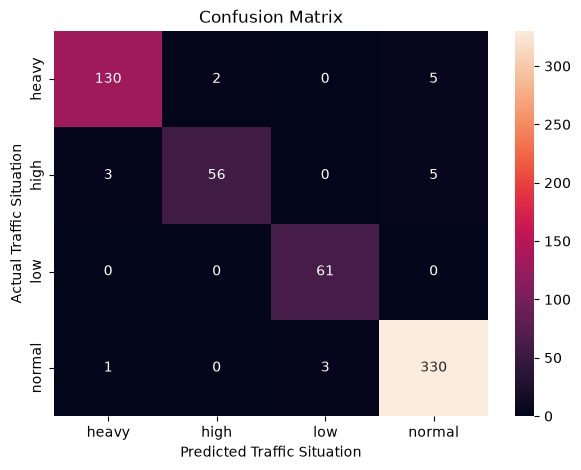

In [47]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Traffic Situation")
plt.ylabel("Actual Traffic Situation")
plt.title("Confusion Matrix")
plt.show()

## 13. Feature Importance

Random Forest can tell us how important each input feature was when making predictions.

In our project, the features are:

- CarCount
- BikeCount
- BusCount
- TruckCount
- Hour

In [48]:
# caculate importance

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [49]:
print(importance)

CarCount      0.353316
TruckCount    0.267591
BusCount      0.221331
BikeCount     0.104591
Hour          0.053171
dtype: float64


### Feature Importance Visualization

A bar chart makes it easier to compare the importance of the different features.

The features with longer bars have greater importance in the Random Forest model.

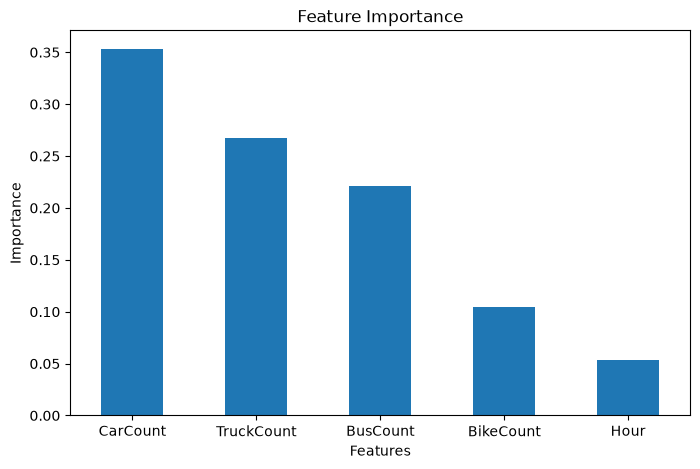

In [50]:
importance.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=0)
plt.show()

### Feature Importance Summary

Feature importance provides insight into which variables the Random Forest model considers useful for predicting traffic situations.

This analysis improves the interpretability of the machine learning model and helps us understand the factors influencing traffic predictions.

## 14. Predict Traffic for New Data

The trained model can be used to predict the traffic situation for a new traffic observation.

This simulates a real-world situation where new vehicle count information is received and the system needs to predict the current traffic condition.

The new observation must contain the same features that were used during model training:

- CarCount
- BikeCount
- BusCount
- TruckCount
- Hour

In [51]:
# creating new traffic data
new_data = pd.DataFrame({
    "CarCount": [100],
    "BikeCount": [20],
    "BusCount": [15],
    "TruckCount": [10],
    "Hour": [18]
})


In [52]:
new_data

,CarCount,BikeCount,BusCount,TruckCount,Hour
0,100,20,15,10,18


In [53]:
# prediction
prediction = model.predict(new_data)

In [54]:
traffic = le.inverse_transform(prediction)

In [55]:
print("Predicted Traffic Situation:", traffic[0])

Predicted Traffic Situation: normal


##  Model Comparison

To determine which classification algorithm performs better for our traffic prediction problem, we will compare:

1. Logistic Regression
2. Random Forest Classifier

Both models will use the same training and testing data.
We will compare their performance using accuracy and classification metrics.

The better-performing model can then be selected for our final traffic prediction application.

In [56]:
from sklearn.linear_model import LogisticRegression

In [57]:
# creating model

log_model =LogisticRegression(max_iter=1000)

In [59]:
# train the model

log_model.fit(X_train,y_train)

c:\Users\muham\OneDrive\Documents\Smart City Traffic Prediction System\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [60]:
# make prediction

log_pred = log_model.predict(X_test)

In [62]:
# calculating Accuraccy

log_accuracy = accuracy_score(y_test,log_pred)

print('logistic regression accuracy: ',
      round(log_accuracy * 100,2), '%')

logistic regression accuracy:  88.09 %


In [65]:
# comparing with random forest accuracy

rf_accuracy = accuracy_score(y_test,y_pred)

print('Random forest Accuracy',
      round(rf_accuracy * 100,2), '%')

print('logistic regression accuracy:',
      round(log_accuracy * 100,2), '%')

Random forest Accuracy 96.81 %
logistic regression accuracy: 88.09 %


## Model Comparison Result

The Random Forest Classifier achieved an accuracy of 96.81%, while Logistic Regression achieved an accuracy of 88.09%.

Random Forest performed better by 8.72 percentage points.

Therefore, based on accuracy, Random Forest is selected as the preferred model for our traffic prediction system.

## Detailed Model Comparison

Accuracy gives us the overall percentage of correct predictions.
To understand the performance of each model in more detail, we will compare:

- Precision
- Recall
- F1-score

In [66]:
# random forest classification report

print('random forest classification')

print(classification_report(y_test,y_pred,
                            target_names=le.classes_))

random forest classification
              precision    recall  f1-score   support

       heavy       0.97      0.95      0.96       137
        high       0.97      0.88      0.92        64
         low       0.95      1.00      0.98        61
      normal       0.97      0.99      0.98       334

    accuracy                           0.97       596
   macro avg       0.96      0.95      0.96       596
weighted avg       0.97      0.97      0.97       596



In [70]:
# logistic regression report

print("Logistic Regression Classification Report")
print(classification_report(
    y_test,
    log_pred,
    target_names=le.classes_
))

Logistic Regression Classification Report
              precision    recall  f1-score   support

       heavy       0.96      0.98      0.97       137
        high       0.76      0.66      0.71        64
         low       0.74      0.69      0.71        61
      normal       0.89      0.92      0.91       334

    accuracy                           0.88       596
   macro avg       0.84      0.81      0.82       596
weighted avg       0.88      0.88      0.88       596



## Model Comparison Conclusion

Random Forest achieved an accuracy of 96.81%, while Logistic Regression achieved 88.09%.

Random Forest also achieved a higher macro F1-score of 0.96 compared with 0.81 for Logistic Regression.

Random Forest performed particularly better in identifying High and Low traffic situations.

So, Random Forest Classifier is selected as the final machine learning model for the Smart City Traffic Prediction System.

##  Save the Final Model

Random Forest was selected as the best-performing model after comparing it with Logistic Regression.

We will save the trained Random Forest model so that it can be loaded later by our Streamlit application without training the model again.

In [71]:
import joblib

In [72]:
# save random forest
joblib.dump(model,'traffic_model.pkl')

['traffic_model.pkl']

In [73]:
# saving the encoder

joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

### Saving the Label Encoder

The Label Encoder is saved because the trained model works with encoded numerical labels.

The encoder allows us to convert the model's numerical prediction back into the original traffic category.

In [76]:
# testing the saved model

loaded_model = joblib.load('traffic_model.pkl')
loaded_encoder = joblib.load('label_encoder.pkl')

In [77]:
# test the model

test_prediction = loaded_model.predict(X_test)

print(test_prediction[:10])

[1 0 2 2 3 2 0 2 2 3]


In [78]:
# converting into original valiues

test_labels = loaded_encoder.inverse_transform(test_prediction)

print(test_labels[:10])

['high' 'heavy' 'low' 'low' 'normal' 'low' 'heavy' 'low' 'low' 'normal']
